In [1]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
iris=load_iris()

In [3]:
X= iris.data
y= iris.target

In [4]:
X.shape

(150, 4)

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Visualize

<Axes: >

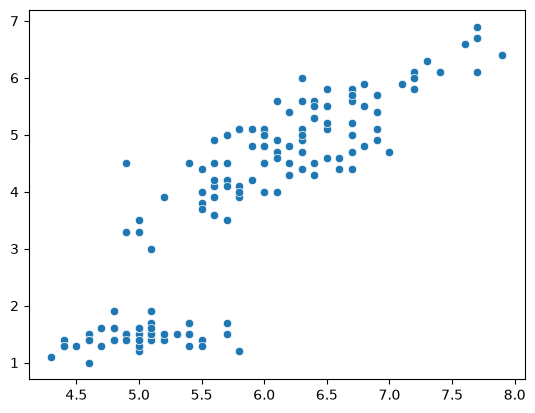

In [6]:
sns.scatterplot(x=X[:,0], y=X[:,2])

In [7]:
scaler=StandardScaler()
X_scaled= scaler.fit_transform(X)

### Dimensionality Reduction

In [10]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
pca_data= pca.fit_transform(X_scaled)

### Elbow Method

In [12]:
wcss=[]

for k in range(1,11):
    kmeans= KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

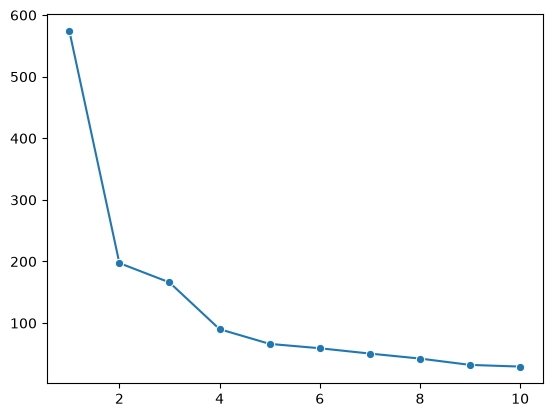

In [13]:
sns.lineplot(x=range(1,11), y=wcss, marker="o")

### KMeans

In [15]:
kmeans= KMeans(
    n_clusters=3,
    random_state=10
)
labels=kmeans.fit_predict(pca_data)

<Axes: >

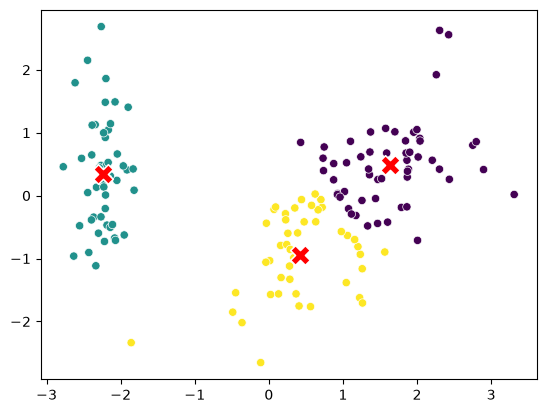

In [19]:
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker="X", color="red", s=200)